Loading Experiment: HUV_Framework_Demo_SFT_vs_RL (ID: 4)

[2. Exploratory Data Analysis]
SFT Accuracy: 85.00%
RL Accuracy:  91.00%

Outcome Distribution:
Outcome
BOTH_CORRECT    169
BOTH_WRONG       17
RL_FIXED         13
RL_BROKE          1
Name: count, dtype: int64


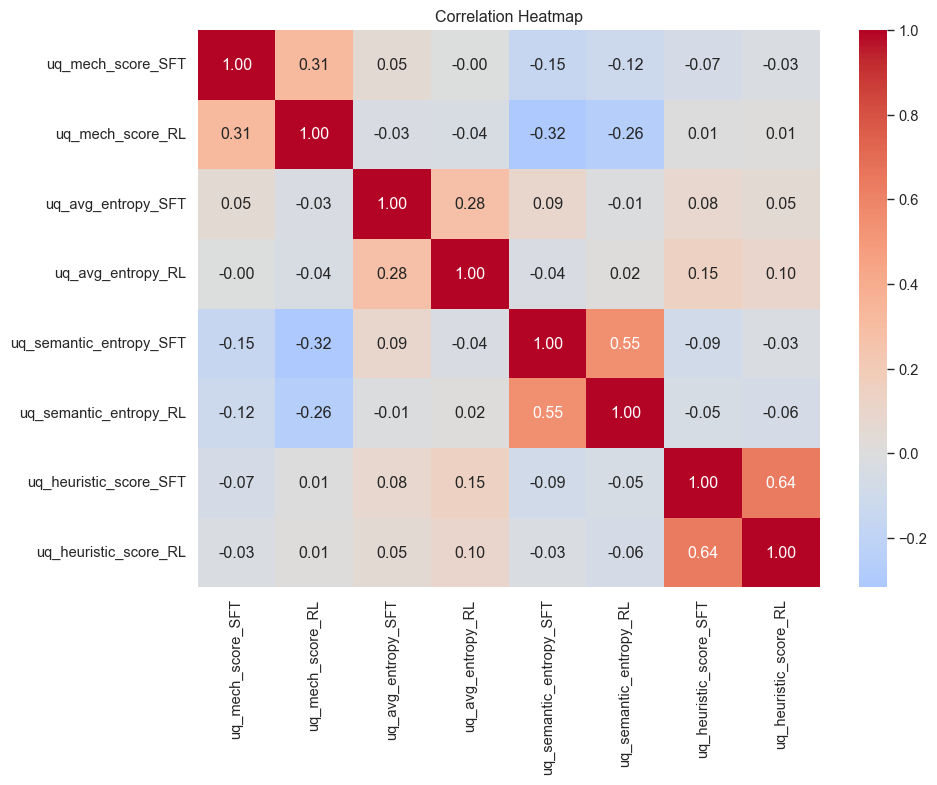


[3. Uncertainty Utility (AUC)]
Target: Predict RL Errors (y=1). Higher AUC is better.
Setup                Self-Check (RL)  Watchdog (SFT)
Metric                                              
uq_avg_entropy              0.454212        0.499084
uq_heuristic_score          0.539683        0.483516
uq_mech_score               0.485806        0.484127
uq_semantic_entropy         0.598443        0.574786

[4. Forensic Analysis: Overconfidence Traps]

--- uq_avg_entropy Traps (1 found) ---
RL is Wrong, but Confidence INCREASED vs SFT.
Q: Shawna's workout goal is 30 situps. On Monday, Shawna was only able to do 12 situps, so she decided ...
RL Ans (Wrong): 18...
Confidence Gain: +0.0651

--- uq_semantic_entropy Traps (4 found) ---
RL is Wrong, but Confidence INCREASED vs SFT.
Q: James decides to replace his car.  He sold his $20,000 car for 80% of its value and then was able to...
RL Ans (Wrong): 00...
Confidence Gain: +0.6730

Analysis Complete.


In [8]:
import sqlite3
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

# ==============================================================================
# 0. Configuration
# ==============================================================================

DB_PATH = "db/results.sqlite"
sns.set_style("whitegrid")

# CRITICAL FIX 1: Updated to match your actual database columns
# 1: Higher value means MORE CONFIDENT
# -1: Higher value means MORE UNCERTAIN
METRIC_DIRECTIONALITY = {
    'uq_mech_score': -1,          # Mechanistic (Higher = Uncertain)
    'uq_avg_entropy': -1,        # Entropy (Higher = Uncertain)
    'uq_semantic_entropy': -1,   # Semantic Entropy (Higher = Uncertain)
    'uq_heuristic_score': -1      # Heuristic (Higher = Confident Language)
}

# ==============================================================================
# 1. Setup and Data Loading
# ==============================================================================

def get_data():
    if not os.path.exists(DB_PATH):
        print(f"Database not found at {DB_PATH}.")
        return None, []
    
    conn = sqlite3.connect(DB_PATH)
    try:
        # Get latest experiment
        exp = pd.read_sql("SELECT experiment_id, experiment_name FROM Experiments ORDER BY run_date DESC LIMIT 1", conn)
        if exp.empty: return None, []
        exp_id = exp.iloc[0]['experiment_id']
        print(f"Loading Experiment: {exp.iloc[0]['experiment_name']} (ID: {exp_id})")

        # Check available columns
        cursor = conn.cursor()
        cursor.execute("PRAGMA table_info(Results)")
        available_columns = [col[1] for col in cursor.fetchall()]
        
        # Filter for metrics present in DB
        metrics_to_load = [m for m in METRIC_DIRECTIONALITY.keys() if m in available_columns]
        metric_selects = ", ".join([f"r.{m}" for m in metrics_to_load])

        # CRITICAL FIX 2 & 3: 
        # - Removed 'JOIN Questions' (Text is in Results table)
        # - Renamed 'answer_generated' -> 'predicted_answer'
        # - Renamed 'answer_gold' -> 'gold_answer'
        query = f"""
        SELECT
            r.question_id_external as q_id,
            r.is_correct,
            {metric_selects},
            r.predicted_answer as answer_text,  -- FIXED
            r.question_text,                    -- FIXED (From Results, not Questions)
            r.gold_answer,                      -- FIXED
            m.training_method
        FROM Results r
        JOIN Models m ON r.model_id = m.model_id
        WHERE r.experiment_id = {exp_id}
        """
        df = pd.read_sql(query, conn)
        
        # Coerce metrics to numeric
        for metric in metrics_to_load:
            df[metric] = pd.to_numeric(df[metric], errors='coerce')
            
        return df, metrics_to_load
        
    except Exception as e:
        print(f"Error loading data: {e}")
        return None, []
    finally:
        conn.close()

def prepare_data(df_raw, metrics_found):
    """Pivots data for SFT vs RL comparison."""
    if df_raw is None or df_raw.empty: return None

    # Pivot
    df_sft = df_raw[df_raw['training_method'] == 'SFT'].set_index('q_id')
    df_rl = df_raw[df_raw['training_method'] == 'RL'].set_index('q_id')

    # Join (compare same questions)
    # We drop text columns from SFT to avoid duplication suffixes
    df_sft_clean = df_sft.drop(columns=['question_text', 'gold_answer', 'training_method'], errors='ignore')
    df = df_rl.join(df_sft_clean, lsuffix='_RL', rsuffix='_SFT', how='inner')

    # 1. Ground Truth (Detect RL Errors)
    df['y_true_RL_error'] = 1 - df['is_correct_RL']
    
    # 2. Outcomes
    def categorize(row):
        s, r = row['is_correct_SFT'], row['is_correct_RL']
        if s and r: return 'BOTH_CORRECT'
        if not s and r: return 'RL_FIXED'
        if s and not r: return 'RL_BROKE'
        return 'BOTH_WRONG'

    df['Outcome'] = df.apply(categorize, axis=1)
    
    # 3. Calculate Deltas
    # Delta > 0 always means "RL became MORE CONFIDENT"
    for metric in metrics_found:
        direction = METRIC_DIRECTIONALITY.get(metric, 0)
        
        # If High Score = Confidence (Dir 1): Delta = RL - SFT
        # If High Score = Uncertainty (Dir -1): Delta = SFT - RL (Decrease in uncertainty is gain in confidence)
        if direction == 1:
            df[f'Delta_{metric}'] = df[f'{metric}_RL'] - df[f'{metric}_SFT']
        else:
            df[f'Delta_{metric}'] = df[f'{metric}_SFT'] - df[f'{metric}_RL']

        # 4. Traps: RL is Wrong, but Confidence Increased
        df[f'Is_Trap_{metric}'] = ((df['is_correct_RL'] == 0) & (df[f'Delta_{metric}'] > 0.05))

    return df

# ==============================================================================
# 2. EDA
# ==============================================================================

def run_eda(df, metrics_found):
    print("\n[2. Exploratory Data Analysis]")
    print(f"SFT Accuracy: {df['is_correct_SFT'].mean():.2%}")
    print(f"RL Accuracy:  {df['is_correct_RL'].mean():.2%}")
    print("\nOutcome Distribution:")
    print(df['Outcome'].value_counts())

    if metrics_found:
        # Correlation Matrix
        cols = []
        for m in metrics_found:
            cols.extend([f'{m}_SFT', f'{m}_RL'])
        
        plt.figure(figsize=(10, 8))
        sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
        plt.title('Correlation Heatmap')
        plt.tight_layout()
        plt.show()

# ==============================================================================
# 3. Predictive Power (AUC)
# ==============================================================================

def analyze_auc(df, metrics_found):
    print("\n[3. Uncertainty Utility (AUC)]")
    print("Target: Predict RL Errors (y=1). Higher AUC is better.")
    
    results = []
    y_true = df['y_true_RL_error']
    if y_true.nunique() < 2: return

    for model in ['RL', 'SFT']:
        prefix = "Self-Check" if model == 'RL' else "Watchdog"
        
        for metric in metrics_found:
            # We want High Score = High Prob of Error
            # If metric is Confidence (1), we flip it (-1)
            # If metric is Uncertainty (-1), we keep it (-1*-1 = 1? No, we multiply score by -direction)
            direction = METRIC_DIRECTIONALITY.get(metric, 0)
            score = df[f'{metric}_{model}'] * (-direction) # Flip confidence to predict error
            
            try:
                auc = roc_auc_score(y_true, score)
                results.append({'Metric': metric, 'Setup': f'{prefix} ({model})', 'AUC': auc})
            except: pass
            
    res_df = pd.DataFrame(results).pivot(index='Metric', columns='Setup', values='AUC')
    print(res_df)

# ==============================================================================
# 4. Forensic Analysis
# ==============================================================================

def run_forensic(df, metrics_found):
    print("\n[4. Forensic Analysis: Overconfidence Traps]")
    
    for metric in metrics_found:
        trap_col = f'Is_Trap_{metric}'
        if trap_col not in df.columns: continue
        
        traps = df[df[trap_col] == True]
        if traps.empty: continue
        
        print(f"\n--- {metric} Traps ({len(traps)} found) ---")
        print("RL is Wrong, but Confidence INCREASED vs SFT.")
        
        # Show top example
        top_trap = traps.sort_values(f'Delta_{metric}', ascending=False).iloc[0]
        print(f"Q: {top_trap['question_text'][:100]}...")
        print(f"RL Ans (Wrong): {str(top_trap['answer_text_RL'])[:50]}...")
        print(f"Confidence Gain: +{top_trap[f'Delta_{metric}']:.4f}")

# ==============================================================================
# Execution
# ==============================================================================

if __name__ == "__main__":
    df_raw, metrics = get_data()
    if df_raw is not None:
        df = prepare_data(df_raw, metrics)
        if df is not None:
            run_eda(df, metrics)
            analyze_auc(df, metrics)
            run_forensic(df, metrics)
            print("\nAnalysis Complete.")